Sujal Mohite 24CO315 TE-B

In [ ]:
import pandas as pd
import numpy as np

# Create dataset
data = {
    'Student_ID': range(1, 21),
    'Math_Score': [78, 85, np.nan, 90, 56, 89, 92, 45, 67, 88, 76, np.nan, 95, 54, 82, 79, 91, 73, 68, 84],
    'Science_Score': [88, 79, 85, np.nan, 60, 90, 94, 40, 70, 86, 75, 80, 96, 58, 83, 77, 89, 72, np.nan, 81],
    'English_Score': [72, 88, 91, 85, 55, np.nan, 93, 50, 65, 87, 78, 82, 97, 60, 80, 76, 90, 74, 69, np.nan],
    'Study_Hours': [2, 3, 4, 5, 1, 6, 7, 1, 2, 5, 3, 4, 8, 2, 6, 3, 7, 4, 2, 5]
}

df = pd.DataFrame(data)

print("Initial Dataset:\n", df)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

Initial Dataset:
     Student_ID  Math_Score  Science_Score  English_Score  Study_Hours
0            1        78.0           88.0           72.0            2
1            2        85.0           79.0           88.0            3
2            3         NaN           85.0           91.0            4
3            4        90.0            NaN           85.0            5
4            5        56.0           60.0           55.0            1
5            6        89.0           90.0            NaN            6
6            7        92.0           94.0           93.0            7
7            8        45.0           40.0           50.0            1
8            9        67.0           70.0           65.0            2
9           10        88.0           86.0           87.0            5
10          11        76.0           75.0           78.0            3
11          12         NaN           80.0           82.0            4
12          13        95.0           96.0           97.0            8
13

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nAfter Handling Missing Values:\n", df)


After Handling Missing Values:
     Student_ID  Math_Score  Science_Score  English_Score  Study_Hours
0            1   78.000000      88.000000      72.000000            2
1            2   85.000000      79.000000      88.000000            3
2            3   77.333333      85.000000      91.000000            4
3            4   90.000000      77.944444      85.000000            5
4            5   56.000000      60.000000      55.000000            1
5            6   89.000000      90.000000      77.333333            6
6            7   92.000000      94.000000      93.000000            7
7            8   45.000000      40.000000      50.000000            1
8            9   67.000000      70.000000      65.000000            2
9           10   88.000000      86.000000      87.000000            5
10          11   76.000000      75.000000      78.000000            3
11          12   77.333333      80.000000      82.000000            4
12          13   95.000000      96.000000      97.000000 

In [ ]:
def handle_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))

# Apply to numeric columns
numeric_cols = ['Math_Score', 'Science_Score', 'English_Score', 'Study_Hours']

for col in numeric_cols:
    handle_outliers(col)

print("\nAfter Handling Outliers:\n", df)


After Handling Outliers:
     Student_ID  Math_Score  Science_Score  English_Score  Study_Hours
0            1   78.000000      88.000000      72.000000          2.0
1            2   85.000000      79.000000      88.000000          3.0
2            3   77.333333      85.000000      91.000000          4.0
3            4   90.000000      77.944444      85.000000          5.0
4            5   56.000000      60.000000      55.000000          1.0
5            6   89.000000      90.000000      77.333333          6.0
6            7   92.000000      94.000000      93.000000          7.0
7            8   47.000000      55.875000      50.000000          1.0
8            9   67.000000      70.000000      65.000000          2.0
9           10   88.000000      86.000000      87.000000          5.0
10          11   76.000000      75.000000      78.000000          3.0
11          12   77.333333      80.000000      82.000000          4.0
12          13   95.000000      96.000000      97.000000       

In [ ]:
import numpy as np

df['Log_Study_Hours'] = np.log(df['Study_Hours'])

print("\nAfter Transformation:\n", df[['Study_Hours', 'Log_Study_Hours']])


After Transformation:
     Study_Hours  Log_Study_Hours
0           2.0         0.693147
1           3.0         1.098612
2           4.0         1.386294
3           5.0         1.609438
4           1.0         0.000000
5           6.0         1.791759
6           7.0         1.945910
7           1.0         0.000000
8           2.0         0.693147
9           5.0         1.609438
10          3.0         1.098612
11          4.0         1.386294
12          8.0         2.079442
13          2.0         0.693147
14          6.0         1.791759
15          3.0         1.098612
16          7.0         1.945910
17          4.0         1.386294
18          2.0         0.693147
19          5.0         1.609438


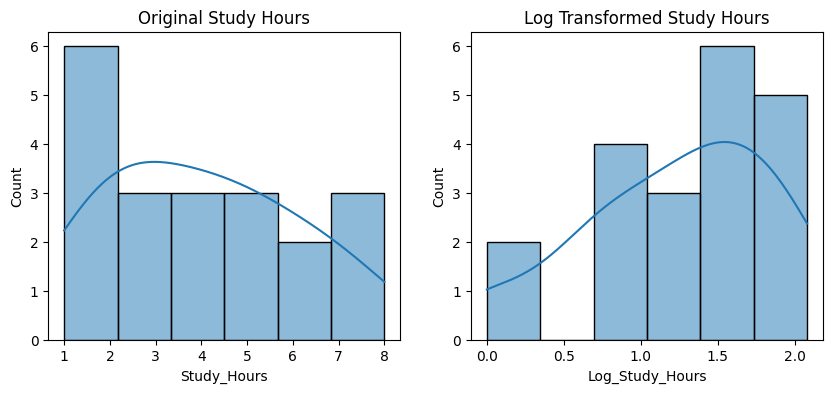

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before vs After transformation
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Study_Hours'], kde=True)
plt.title("Original Study Hours")

plt.subplot(1,2,2)
sns.histplot(df['Log_Study_Hours'], kde=True)
plt.title("Log Transformed Study Hours")

plt.show()